In [26]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns

# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "df_prepared.pkl", "rb") as f:
    df = pickle.load(f)

with open(data_path + "merged_df_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)

print("DataFrames loaded successfully:")
print(f"  df shape: {df.shape}")
print(f"  merged_df shape: {merged_df.shape}")

DataFrames loaded successfully:
  df shape: (65006, 21)
  merged_df shape: (65006, 27)


# Cluster Analysis

To conduct a clustering of the registered users, we first need to extract all session with a registered user and store these instances in a new variable

In [27]:
registered_users_df = merged_df[merged_df['isRegisteredUser'] == True].copy()

# Cyclic encoding of hour for correct circular averaging
registered_users_df['hour_sin'] = np.sin(2 * np.pi * registered_users_df['hour'] / 24)
registered_users_df['hour_cos'] = np.cos(2 * np.pi * registered_users_df['hour'] / 24)

In [28]:
print(f"Total sessions in merged_df: {len(merged_df)}")
print(f"Sessions from registered users: {len(registered_users_df)}")
print(f"Unique registered users to cluster: {registered_users_df['userID'].nunique()}")

Total sessions in merged_df: 65006
Sessions from registered users: 47815
Unique registered users to cluster: 1006


In [29]:
registered_users_df['siteID'].dtype
registered_users_df['siteID_numeric'] = (registered_users_df['siteID'] == '1').astype(int)

In [30]:
registered_users_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47815 entries, 2 to 65005
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   id                  47815 non-null  object                             
 1   connectionTime      47815 non-null  datetime64[ns, America/Los_Angeles]
 2   disconnectTime      47815 non-null  datetime64[ns, America/Los_Angeles]
 3   doneChargingTime    47815 non-null  datetime64[ns, America/Los_Angeles]
 4   kWhDelivered        47815 non-null  float64                            
 5   sessionID           47815 non-null  object                             
 6   siteID              47815 non-null  object                             
 7   spaceID             47815 non-null  object                             
 8   stationID           47815 non-null  object                             
 9   userID              47815 non-null  object  

In [31]:
# Aggregating statistics to User Level
user_profiles = registered_users_df.groupby('userID').agg(
    avg_energy=('kWhDelivered', 'mean'),
    std_energy=('kWhDelivered', 'std'),
    total_energy=('kWhDelivered', 'sum'),
    avg_kWh_req=('kWhRequested', 'mean'),
    frequency=('sessionID', 'count'),
    avg_duration=('session_duration', 'mean'),
    total_charging_duration=('charging_duration', 'sum'),
    avg_charging_duration=('charging_duration', 'mean'), 
    avg_hour_sin=('hour_sin', 'mean'),  # Cyclic mean instead of avg_start_hour
    avg_hour_cos=('hour_cos', 'mean'),  # Cyclic mean instead of avg_start_hour
    pct_weekend_sessions=('is_weekend', 'mean'),
    avg_minutes_available=('minutesAvailable', 'mean'),
    pct_site_1=('siteID_numeric', 'mean')
)

user_profiles['avg_energy_per_session'] = user_profiles['total_energy'] / user_profiles['frequency']
user_profiles['avg_charging_speed'] = user_profiles['total_energy'] / (user_profiles['total_charging_duration'] / 60)
user_profiles['std_energy_pct'] = user_profiles['std_energy'] / user_profiles['avg_energy']
user_profiles['kWh_requested_delta'] = user_profiles['avg_kWh_req'] - user_profiles['avg_energy']
user_profiles['session_duration_delta'] = user_profiles['avg_duration'] - user_profiles['avg_charging_duration']

In [32]:
user_profiles.head()

,avg_energy,std_energy,total_energy,avg_kWh_req,frequency,avg_duration,total_charging_duration,avg_charging_duration,avg_hour_sin,avg_hour_cos,pct_weekend_sessions,avg_minutes_available,pct_site_1,avg_energy_per_session,avg_charging_speed,std_energy_pct,kWh_requested_delta,session_duration_delta
userID,,,,,,,,,,,,,,,,,,
1.0,1.659000,NaN,1.659000,5.000000,1,1.404444,1.241111,1.241111,-0.258819,-0.965926,0.0,150.000000,0.0,1.659000,80.202328,NaN,3.341000,0.163333
17.0,1.471000,NaN,1.471000,13.840000,1,0.302222,0.300278,0.300278,-0.707107,-0.707107,1.0,72.000000,0.0,1.471000,293.927845,NaN,12.369000,0.001944
22.0,18.754998,8.609281,1087.789899,36.906034,58,6.354296,245.049722,4.224995,0.569341,-0.642777,0.0,462.034483,0.0,18.754998,266.343472,0.459039,18.151036,2.129301
43.0,43.266000,NaN,43.266000,43.400000,1,8.282222,6.988333,6.988333,0.707107,-0.707107,1.0,469.000000,0.0,43.266000,371.470546,NaN,0.134000,1.293889
45.0,8.069000,NaN,8.069000,17.500000,1,3.551389,2.157500,2.157500,-0.965926,-0.258819,1.0,134.000000,0.0,8.069000,224.398610,NaN,9.431000,1.393889


In [33]:
user_profiles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1006 entries, 1.0 to 19923.0
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avg_energy               1006 non-null   float64
 1   std_energy               843 non-null    float64
 2   total_energy             1006 non-null   float64
 3   avg_kWh_req              1006 non-null   float64
 4   frequency                1006 non-null   int64  
 5   avg_duration             1006 non-null   float64
 6   total_charging_duration  1006 non-null   float64
 7   avg_charging_duration    1006 non-null   float64
 8   avg_hour_sin             1006 non-null   float64
 9   avg_hour_cos             1006 non-null   float64
 10  pct_weekend_sessions     1006 non-null   float64
 11  avg_minutes_available    1006 non-null   float64
 12  pct_site_1               1006 non-null   float64
 13  avg_energy_per_session   1006 non-null   float64
 14  avg_charging_speed      

For the **std_energy_pct** we use the percentage of the standard deviation of delivered energy as absolute values can differ when the avg_energy is overall higher. For user who have only one session we filled the empty deviation with a 0. 

In [34]:
print(user_profiles['std_energy_pct'].isna().sum())
# use a indicator fo user with only one session & fill std_energy NaN with median
user_profiles['single_session_user'] = (user_profiles['frequency'] == 1).astype(int)
user_profiles['std_energy_filled'] = user_profiles['std_energy_pct'].fillna(0)

163


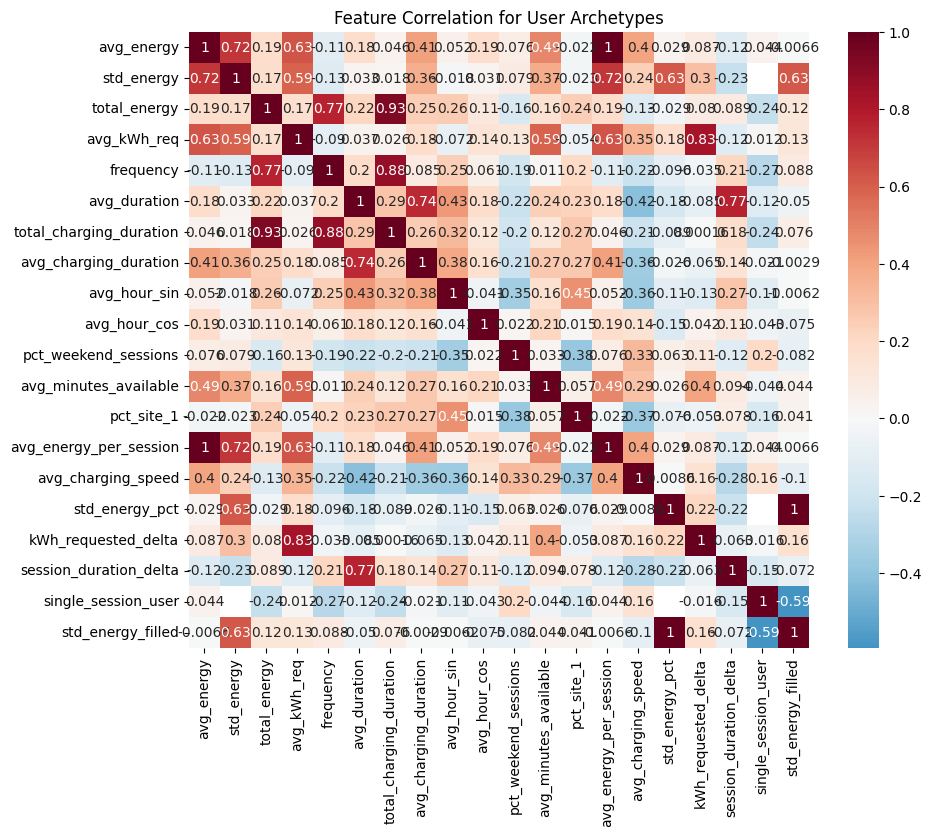

In [35]:
corr_matrix = user_profiles.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation for User Archetypes')
plt.show()

We use a correlation matrix to identify redundant features before clustering. If two features are highly correlated —such as `avg_session_duration` and `avg_charging_duration` (0.74)— including both would effectively double their weight in the distance calculation, biasing the clusters.

The matrix also reveals unexpected relationships between variables. For instance, while we would intuitively expect a strong positive correlation between `avg_duration` and `avg_energy`, they show a surprisingly low correlation of only 0.18. This suggests that stay time is not a reliable predictor of energy delivered, indicating distinct user behaviors, which we will explore further in the following analysis.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

features_to_standardize = ['kWh_requested_delta', 'avg_energy', 
    'frequency','avg_duration',
     'avg_hour_sin', 'avg_hour_cos',
      'session_duration_delta']
features_to_passthrough = [] # if we want to include features such as 'pct_site_1' without scaling
cluster_features = features_to_standardize + features_to_passthrough

ct = ColumnTransformer([
    ('scaled_features', StandardScaler(), features_to_standardize),
    ('passthrough_features', 'passthrough', features_to_passthrough)
])

user_profiles_scaled_array = ct.fit_transform(user_profiles)

user_profiles_scaled = pd.DataFrame(
    user_profiles_scaled_array,
    columns=cluster_features,
    index=user_profiles.index
)

We chose to limit the clustering analysis on fewer features for the following reasons:
* Including more features led to overlap between groups, making it difficult to identify distinct clusters.
* The resulting archetypes are easier to define and understand.

We chose `avg_duration` and `avg_energy` because despite the expectation that energy consumption would increase with session duration, these features showed a low correlation of only 0.18. This low correlation indicates the existence of two very different behaviors: users who treat the station primarily for parking (high duration, low energy) and those who use it for efficient charging (high energy, relatively lower duration). Our aim is to confirm these groups through clustering.

We choose the following features to cover many different dimensions which gives us better interpreting clusters.

* Energy and Demand
  * std_energy
* Frequency and duration of use
  * frequency
  * avg_duration
* Temporal Behavior
  * avg_hour_sin, avg_hour_cos (cyclic encoding of average start hour to correctly handle the circular nature of time — e.g. a user charging at 23:00 and 01:00 should average to midnight, not noon)
* Charging Behavior/ Efficiency
  * avg_charging_speed

In [37]:
print(user_profiles_scaled.shape)

(1006, 7)


In [38]:

outliers = (np.abs(user_profiles_scaled[[ 'kWh_requested_delta', 'avg_energy',
    'frequency','avg_duration',
    'avg_hour_sin', 'avg_hour_cos',
    'session_duration_delta']]) > 2).any(axis=1)
print(f"Anzahl der Nutzer mit mindestens einem extremen Feature (Z > 2): {outliers.sum()}")

Anzahl der Nutzer mit mindestens einem extremen Feature (Z > 2): 193


The features `std_energy`, `frequency`, `avg_duration`, `avg_hour_sin`, `avg_hour_cos` and `charging_speed` contain outliers that could negatively impact the clustering process. To address this we, identify and remove outliers using the 1 sigma threshold, which has proven to improve the Silhouette Score later the best.

In [39]:
user_profiles_scaled = user_profiles_scaled[~outliers].copy()
user_profiles = user_profiles[~outliers].copy()

### Hyperparameter Tuning

We decided to use 5 clusters for our analysis because:
* The Silhouette analysis shows a clear peak at $k=5$ with a score of approximately 0.325. This indicates that five clusters provide the best balance between internal cohesion and separation between groups.
* In the Elbow plot, the "bend" or elbow occurs at $k=4 or k=5$. Adding a more cluster results in significantly diminishing returns in terms of reducing the Total Variance (Inertia), suggesting that four or five is the "sweet spot" for capturing the data's underlying structure.

* **with the Silhouette suggesting four and the elbow method four or five, we decide to use k=5**

### Cluster Alg implementation

#### I decided to choose KMeans, however this is GMM implementation.

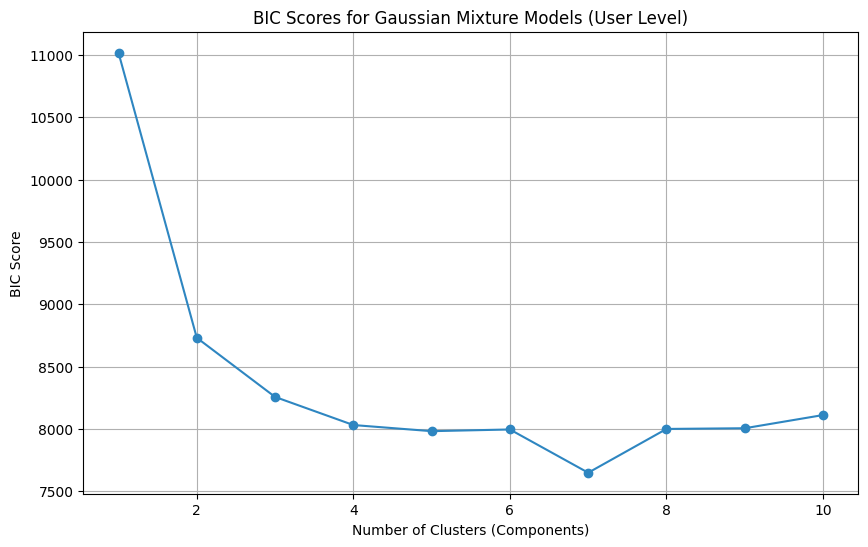

In [40]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# 1. BIC-Score Berechnung zur Bestimmung der optimalen Cluster-Anzahl
bic_scores = []
n_components_range = range(1, 11)  # Bei 1000 Usern reichen oft 1-10 Komponenten

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(user_profiles_scaled)
    bic_scores.append(gmm.bic(user_profiles_scaled))

# Plot BIC
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic_scores, marker='o', color='#2E86C1')
plt.title('BIC Scores for Gaussian Mixture Models (User Level)')
plt.xlabel('Number of Clusters (Components)')
plt.ylabel('BIC Score')
plt.grid(True)
plt.show()

In [59]:
optimal_components = 5
best_gmm = GaussianMixture(n_components=optimal_components)
best_gmm.fit(user_profiles_scaled)
user_profiles['Clusters'] = best_gmm.predict(user_profiles_scaled)

In [60]:
# Convert cyclic hour features back to interpretable avg_start_hour for reporting
user_profiles['avg_start_hour'] = (
    np.arctan2(user_profiles['avg_hour_sin'], user_profiles['avg_hour_cos']) * 24 / (2 * np.pi)
) % 24

# Display features: replace avg_hour_sin & avg_hour_cos with a single readable avg_start_hour
display_features = ['kWh_requested_delta', 'avg_energy', 'frequency', 'avg_duration', 'avg_start_hour', 'session_duration_delta']

print("Cluster features (for model):", cluster_features)
print("Display features (for report):", display_features)

Cluster features (for model): ['kWh_requested_delta', 'avg_energy', 'frequency', 'avg_duration', 'avg_hour_sin', 'avg_hour_cos', 'session_duration_delta']
Display features (for report): ['kWh_requested_delta', 'avg_energy', 'frequency', 'avg_duration', 'avg_start_hour', 'session_duration_delta']


### Clustering Results Analysis

In [61]:
cluster_mapping = {
    0: 'Cluster 1', 
    1: 'Cluster 2',
    2: 'Cluster 3',
    3: 'Cluster 4',
    4: 'Cluster 5',
   
    
}
user_profiles['Clusters_Name'] = user_profiles['Clusters'].map(cluster_mapping)

cluster_summary = user_profiles.groupby('Clusters_Name')[display_features].mean()

print("--- ARCHETYPEN REPORT (Mean per cluster) ---")

print(cluster_summary.T) 

print("\nNumber of users per archetype:")
counts = user_profiles['Clusters_Name'].value_counts()
print(counts)

--- ARCHETYPEN REPORT (Mean per cluster) ---
Clusters_Name           Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5
kWh_requested_delta     14.131804  11.254783   5.657619  10.855457  13.890400
avg_energy              17.945896  18.214845   8.014846  12.713592  14.158790
frequency               33.342282  46.882353  66.822430  14.603175   3.105263
avg_duration             4.429067   7.529360   6.269130   3.454918   2.145585
avg_start_hour          10.640169   7.748126   9.506542  14.711558  13.270731
session_duration_delta   0.859526   2.592528   3.170399   1.075689   0.001458

Number of users per archetype:
Clusters_Name
Cluster 3    214
Cluster 5    171
Cluster 2    153
Cluster 1    149
Cluster 4    126
Name: count, dtype: int64


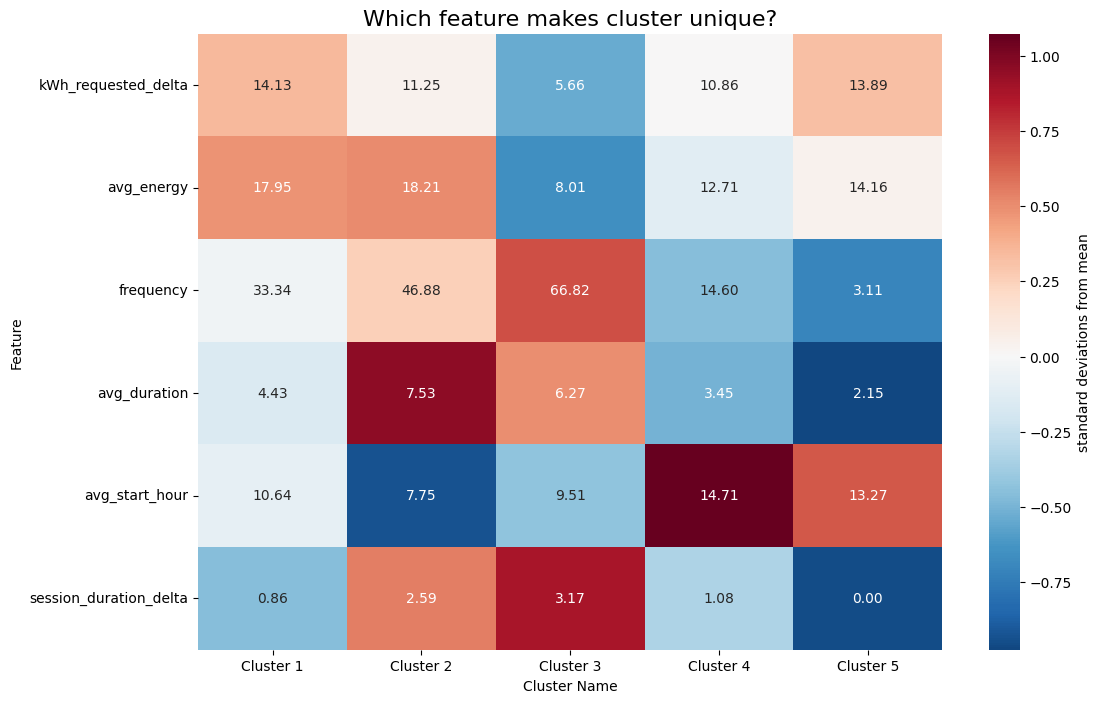

In [62]:
import seaborn as sns

cluster_summary = user_profiles.groupby('Clusters_Name')[display_features].mean()

# (Z-Score der Mittelwerte)
summary_scaled = (cluster_summary - user_profiles[display_features].mean()) / user_profiles[display_features].std()

plt.figure(figsize=(12, 8))
sns.heatmap(summary_scaled.T, 
            annot=cluster_summary.T,
            fmt=".2f", 
            cmap="RdBu_r", 
            center=0,
            cbar_kws={'label': 'standard deviations from mean'})

plt.title('Which feature makes cluster unique?', fontsize=16)
plt.xlabel('Cluster Name')
plt.ylabel('Feature')
plt.show()

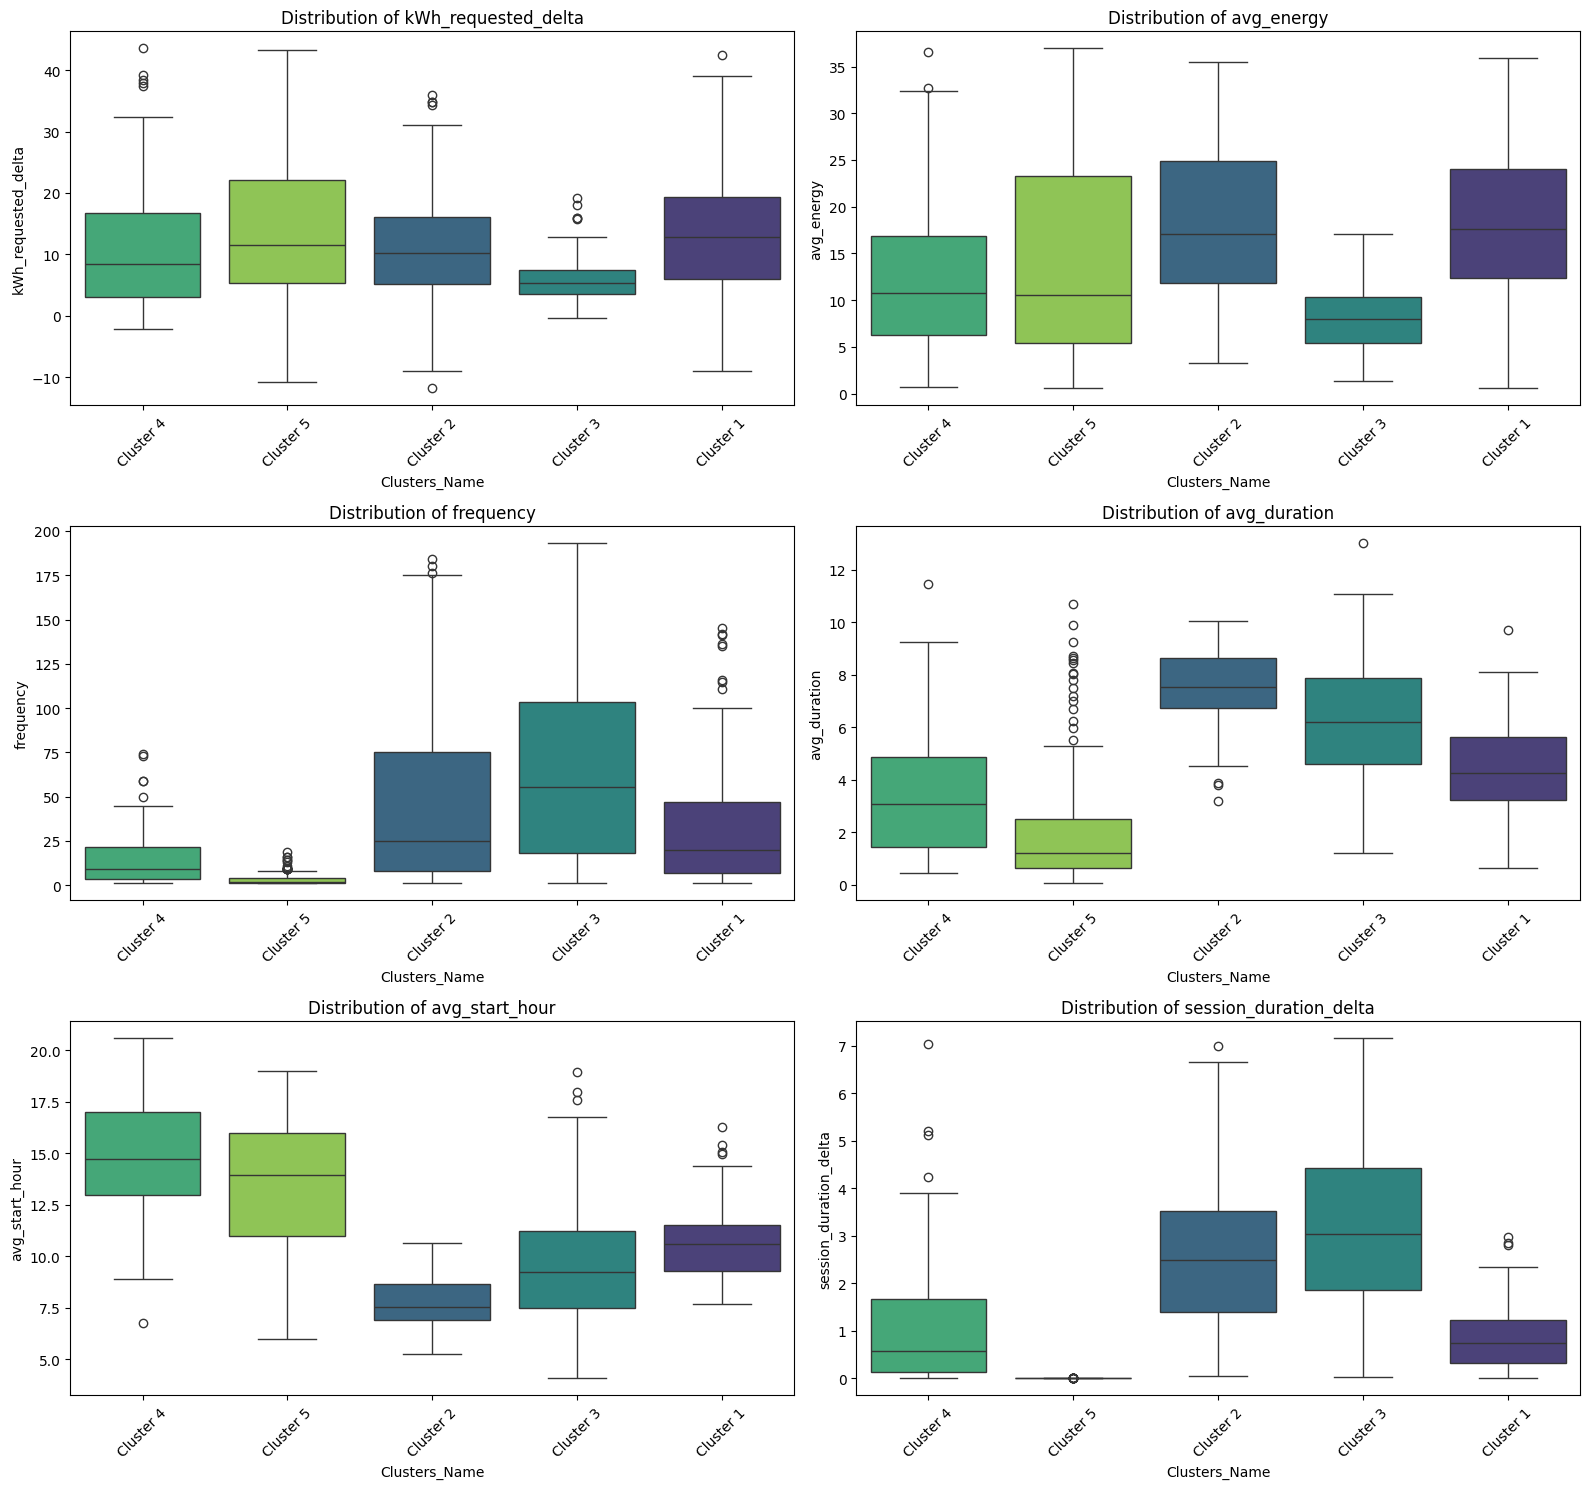

In [63]:
import math


num_features = len(display_features)
cols = 2
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

cluster_order = sorted(
    user_profiles['Clusters_Name'].unique(), 
    key=lambda s: int(s.split()[-1])
)

for i, feature in enumerate(display_features):
    sns.boxplot(
        x='Clusters_Name', 
        y=feature, 
        data=user_profiles, 
        ax=axes[i], 
        palette='viridis', 
        hue='Clusters_Name', 
        hue_order=cluster_order,
        legend=False
    )
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', labelrotation=45)

# Remove any empty subplots if num_features is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

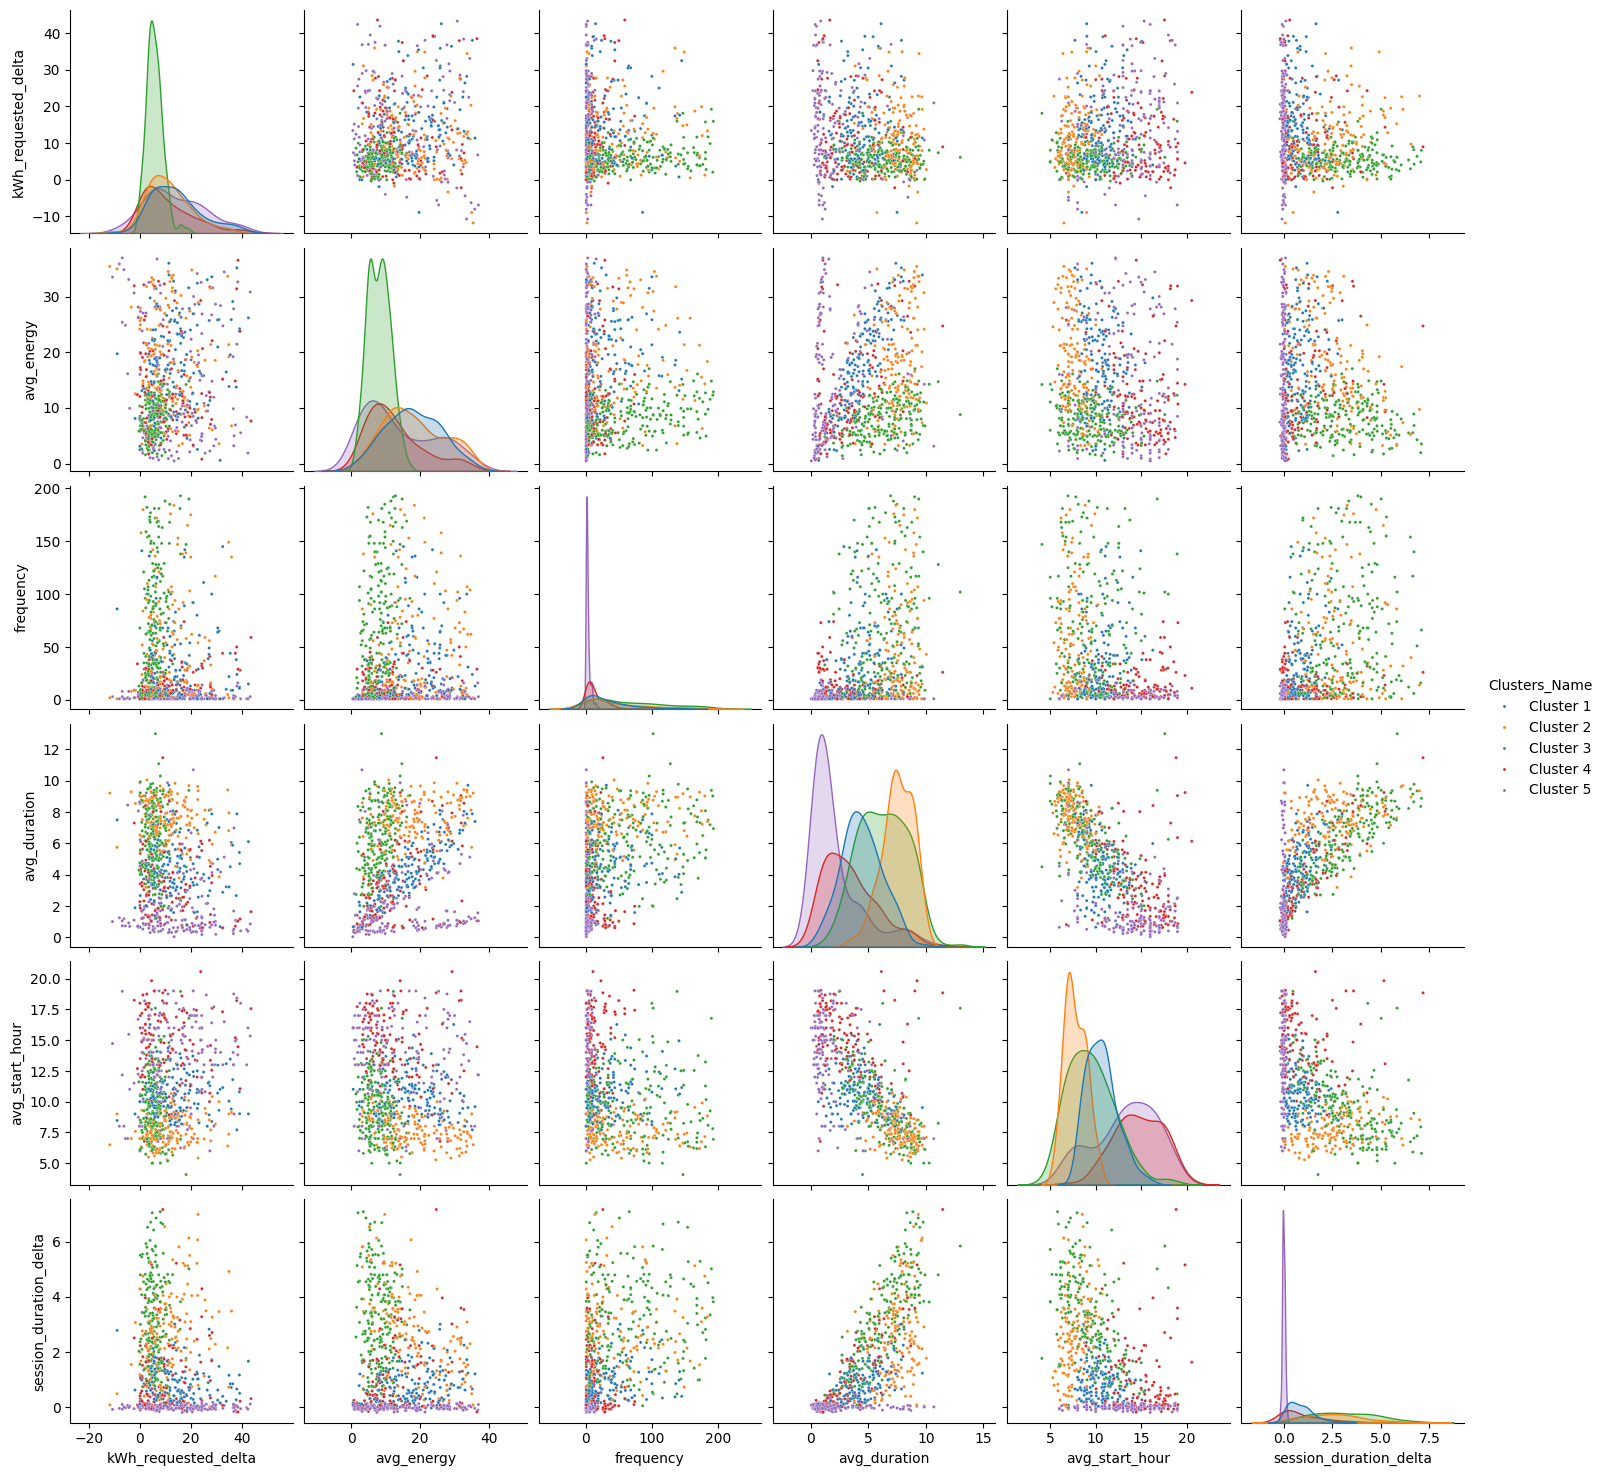

In [ ]:
example_features = display_features
user_profiles['session_duration_delta'] = user_profiles['session_duration_delta'] + np.random.normal(0, 0.05, len(user_profiles))

hue_order = sorted(user_profiles['Clusters_Name'].unique())
sns.pairplot(
    user_profiles[example_features + ['Clusters_Name']], 
    diag_kind='kde', 
    hue='Clusters_Name', 
    hue_order=hue_order,
    plot_kws={'s':5}
    
)
plt.show()

* Cluster 1: New or one-off users
  * single charging event only as frequency = 1
  * medium session duration & above-average charging speed
  * no established temporal or behavioral pattern
  * **=> true one-time or newly onboarded users; suited for activation, education, and conversion campaigns**

* Cluster 2: Light infrequent users
  * low frequency  and moderate session duration
  * low energy variability and standard charging speed
  * higher start hour
  * **=> occasional users with low dependency on charging; suited for Pay-per-use models and not for complex pricing structures or programs**

* Cluster 3: Regular long-session chargers
  * moderate frequency combined with medium sessions
  * high std_energy & charging speed shows big dips in energy demand (maybe due to variety of driving profiles)
  * flexible start times suggests adaptable charging windows
  * **=> steady repeat users; suited for general retention & light optimization**

* Cluster 4: Daily heavy chargers
  * charge very frequently with a long session duration
  * lowest charging speed with low to moderate energy variability
  * earliest start hour
  * **=> heavy routinme users with strong habit pattern; ideal for tarifs, loyalty programs &  reliable forecasting**  

* Cluster 5: Fast Charging Specialists
  * very high charging speed
  * very short sessions with low frequency
  * late start hours
  * **=> mobile, time-sensitive users; critical for HPC utilization, througput optimization, and cost recovery of fast-charging assets**